## Real-Time Pedestrian Detection using Pre-trained YOLO v11 (Ultralytics)

### Overview

Pedestrian detection is a fundamental computer vision task used in applications such as:

- Autonomous driving

- Video surveillance

- Smart cities

- Human-computer interaction

In this tutorial, we will use a pre-trained YOLO v11 model provided by Ultralytics to perform real-time pedestrian detection on images and video streams. YOLO11 is the latest iteration in the famous YOLO series of object detectors. For beginners, the most important thing to know is that YOLO is a single-stage detector. Unlike older methods that looked at an image multiple times to find objects, YOLO "looks only once," making it incredibly fast and efficient for real-time video.

The goal is not to train a model from scratch, but to understand how to apply an existing object detection model effectively for real-time inferencing.

In this notebook, we will discuss:

- Understand what object detection is and how YOLO works (at a high level)

- Set up the environment and install required libraries

- Load a pre-trained YOLO v11 model

- Prepare input data (images and video)

- Run real-time pedestrian detection

- Visualise detection results with bounding boxes

- Build a simple inference pipeline

### Key Learnings

By the end of this tutorial, you will be able to:

- Explain what YOLO is and why it is used for real-time detection

- Use Ultralytics YOLO v11 with their pre-trained object detection model

- Detect pedestrians using the COCO “person” class

- Perform real-time inference on images, videos, and webcam streams

### What is YOLO?

YOLO stands for You Only Look Once. Unlike older methods that scan images multiple times, YOLO:

- Looks at the image once

- Predicts bounding boxes and class labels in a single forward pass

- Is extremely fast, making it ideal for real-time applications

Ultralytics provides a simple Python interface for using YOLO models.

### Setup and Installation
First, we need to install the core library. YOLO11 is part of the `ultralytics` package. Along with it, we will require a few other libraries like `open-cv`

In [3]:
# !pip install ultralytics opencv-python matplotlib --quiet

In [ ]:
# Let us import the required libraries:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from IPython.display import HTML
from base64 import b64encode
from IPython.display import Video

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/tushar/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


We initialise the model by calling the `YOLO` class. The first time you run this, it will automatically download the weights file (approx. 5-10 MB for the Nano version). We will use YOLO v11 Nano for speed for this tutorial. However, please feel free to play around with other versions.

In [2]:
# Load a pre-trained YOLO11n model
model = YOLO("yolo11n.pt")

# Verify the classes the model can detect
# 'person' is usually at index 0 in the COCO dataset
print(model.names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

As you can see, the base pre-trained model is developed to detect multiple classes (types of object) and not just pedetrians.
In general, the model predicts:

- Bounding box coordinates

- Confidence score

- Class label (e.g., person, car, dog)

We will filter detections to only show pedestrians.

### Dataset Used  In Pre-trained Models

YOLO models are commonly trained on the COCO dataset, which contains 80 object categories.
One of these categories is:

Class ID 0 → "person"

This means we can perform pedestrian detection without any custom dataset. However, you will need a sample video or an image file for the real-time inferencing process.

### Input Types Supported

Before we get started with the inference pipeline, let us discuss the input types supported by YOLOv11. YOLO v11 supports:

- Images (.jpg, .png)

- Videos (.mp4)

- Webcam streams (real-time)

In this tutorial, we will demonstrate image based inference and Video inference

### Inference Pipeline
This is the core component where we read images or image frames from a video, pass them to YOLO, and display the results. We will filter the results so that only the "person" class (class ID 0) is displayed.

#### 1. Inference on Static Image

In [6]:
image_path = "data/pedestrian_image.jpg"
results = model(image_path, conf=0.4, classes=[0])


image 1/1 /home/tushar/data/pedestrian_image.jpg: 448x640 1 person, 37.6ms
Speed: 4.9ms preprocess, 37.6ms inference, 44.2ms postprocess per image at shape (1, 3, 448, 640)


(np.float64(-0.5), np.float64(611.5), np.float64(407.5), np.float64(-0.5))

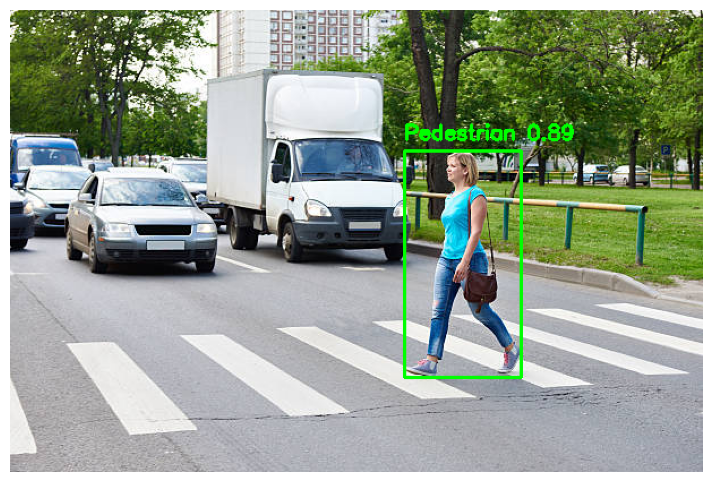

In [7]:
# Now displaying the results
detections = results[0].boxes
image = cv2.imread(image_path)

for box in detections:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    confidence = float(box.conf[0])

    label = f"Pedestrian {confidence:.2f}"

    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        image,
        label,
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

#### 2. Real-time inference from video

In [ ]:
# from google.colab.patches import cv2_imshow   #for google colab

# Open the video file or webcam (0 for webcam)
video_path = "data/pedestrian_video.mp4"

In [23]:
Video(video_path, embed=True)

For the video, we need to write a pre-processing pipeline first

In [16]:
cap = cv2.VideoCapture(video_path)

# Get video properties for the writer
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Define the codec and create VideoWriter object
# 'avc1' or 'mp4v' are common; we will convert to H.264 for browser compatibility
out = cv2.VideoWriter('data/output_annotated.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # Run detection (class 0 is person)
    results = model(frame, classes=[0], conf=0.5, verbose=False)
    result = results[0]

    # Get annotated frame
    annotated_frame = frame.copy()

    # Loop through detections and draw manually
    for box in result.boxes:
        # Get coordinates
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Draw the box (Bayer Green: 0, 255, 0)
        cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Draw the custom label "pedestrian"
        label = f"pedestrian {float(box.conf):.2f}"
        cv2.putText(annotated_frame, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Write the frame to our output file
    out.write(annotated_frame)

cap.release()
out.release()

print("Processing complete. Preparing video for display...")

Processing complete. Preparing video for display...


Run the following set of commands only if you are running the code on Google Colab to avoid any video rendering issue.

In [ ]:
# !ffmpeg -y -i /content/output_annotated.mp4 -vcodec libx264 -pix_fmt yuv420p -movflags +faststart final_output_video.mp4

In [21]:
output_path = "data/output_annotated.mp4"
Video(output_path, embed=True)

And, thus we have a nice pipeline for running real-time object detection. As a future step, you can trying running this on a streaming web-cam video.

### Conclusion

We have now built a functional real-time pedestrian detector! YOLO11 makes it incredibly easy to move from an idea to a working prototype with just a few lines of code. As next steps, please try different models by swapping `yolo11n.pt` for `yolo11x.pt` to see how accuracy improves (but speed drops).You can try adjusting confidence. You can change the conf=0.5 parameter, lowering it captures more people but may cause "ghost" detections. Also, try adding a counter that tracks how many people are in the frame at once.